In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Load Data
df_songs = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/songs_fact.csv", index_col=0)
df_metrics = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/platform_metrics_dim.csv", index_col=0)

In [2]:
# Filter df_metrics for only YouTube
df_youtube = df_metrics[df_metrics["platform_name"] == "YouTube"].copy()

# Merge df_youtube & df_songs
df_merged = df_songs.merge(df_youtube, on="song_id", how="inner")

# Drop release_date_original and release_date_original.1
df_merged = df_merged.drop(columns=["release_date_original", "release_date_original.1"])

# Convert release_date  to datetime
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], dayfirst=False, errors="coerce")

In [20]:
# Calculate engagement metrics
# Engagement rate = (likes + comments) / views * 100
df_merged["engagement_rate"] = (
    (df_merged["likes"] + df_merged["comments"]) / df_merged["views"].replace(0, np.nan) * 100
).round(2)

# like rate = (likes / views)* 100
df_merged["like_rate"] = (
    (df_merged["likes"] / df_merged["views"]) * 100
).round(2)

# Comment rate = (comments / views)* 100
df_merged["comment_rate"] = (
    (df_merged["comments"] / df_merged["views"]) * 100
).round(2)

In [24]:
# Define Undervalued Criteria
# Calculate benchmark averages
avg_views = df_merged["views"].mean()
avg_engagement = df_merged["engagement_rate"].mean()
median_views = df_merged["views"].median()
median_engagement = df_merged["engagement_rate"].median()

In [40]:
# Define undervalued songs:
# 1. Engagement rate ABOVE average (fans love it)
# 2. Views BELOW average (not enough people have heard it)
# 3. Minimum threshold of 5,000 views (to avoid statistical noise)

undervalued = df_merged[
                        (df_merged["engagement_rate"] > avg_engagement) &
                        (df_merged["views"] < avg_views) &
                        (df_merged["views"] >= 5000)
].copy()

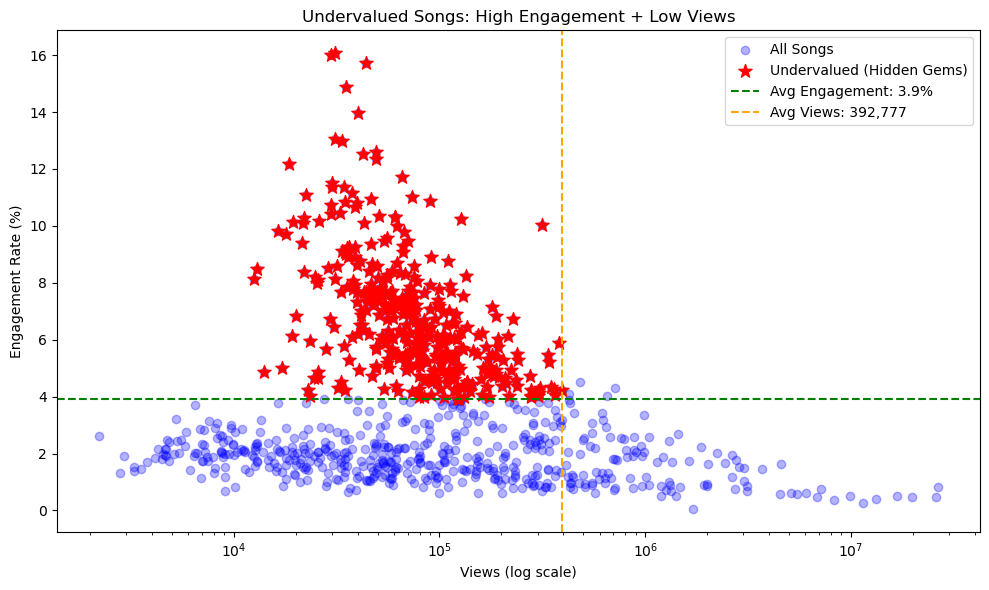

In [55]:

# Calculate a "potential score" - the gap between engagement and views
# Higher score = more undervalued
undervalued['potential_score'] = (
    undervalued['engagement_rate'] / undervalued['views'] * 1000000
)

# Sort by highest engagement rate (most loved songs with low views)
undervalued = undervalued.sort_values('engagement_rate', ascending=False)


# Select what to show
results = undervalued[['title', 'views', 'likes', 'comments', 'engagement_rate']].head(10).copy()

# Format for readability
results['views'] = results['views'].apply(lambda x: f"{x:,.0f}")
results['likes'] = results['likes'].apply(lambda x: f"{x:,.0f}")
results['comments'] = results['comments'].apply(lambda x: f"{x:,.0f}")
results['engagement_rate'] = results['engagement_rate'].round(2).astype(str) + '%'


# Visualization
plt.figure(figsize=(10, 6))

# Plot all songs as blue dots
plt.scatter(df_merged['views'],df_merged['engagement_rate'], alpha=0.3, color='blue', label='All Songs')

# Highlight undervalued songs as red stars
plt.scatter(undervalued['views'], undervalued['engagement_rate'], 
            color='red', s=100, marker='*', label='Undervalued (Hidden Gems)')

# Add benchmark lines
plt.axhline(y=avg_engagement, color='green', linestyle='--', label=f'Avg Engagement: {avg_engagement:.1f}%')
plt.axvline(x=avg_views, color='orange', linestyle='--', label=f'Avg Views: {avg_views:,.0f}')

plt.xscale('log')
plt.xlabel('Views (log scale)')
plt.ylabel('Engagement Rate (%)')
plt.title('Undervalued Songs: High Engagement + Low Views')
plt.legend()
plt.tight_layout()
plt.show()



Insights:
- Engagement rate declines sharply as view counts increase – Songs with 10,000-20,000 views have engagement rates of 3.5% to 2.8%, while songs with over 500,000 views drop below 1% engagement
- Low-view songs show the highest fan passion – The most engaged audiences are found on songs with fewer than 100,000 views, where engagement rates range from 3.5% down to 1.2%
- High-view songs attract passive listeners – Once a song exceeds 500,000 views, engagement rate consistently falls below 0.5%, meaning the majority of viewers are casually listening without interacting

Recommendations
- Prioritize promoting undervalued songs with 10,000-100,000 views – These have the highest engagement rates (2-3.5%), proving the content resonates, but reach is still limited
- Don't expect viral hits to maintain high engagement – Massive view counts naturally dilute engagement rates; this is normal and not a sign of poor quality
- Use engagement rate (not just views) to identify re-promotion candidates – Songs with 50,000-100,000 views and 2%+ engagement are better targets for additional promotion than songs with millions of views and near-zero engagement

